---
title: Critical Regions and Alpha
---

# Critical Regions in Visualising Significance Level (Alpha)

The **critical region** (often called the rejection region) is the physical area on a probability distribution curve that represents your Significance Level ($\alpha$). It is the visual manifestation of your "burden of proof."

If your calculated test statistic falls anywhere inside this shaded area, the result is considered statistically significant, and you reject the null hypothesis ($H_0$). If it falls in the unshaded main body of the curve, you fail to reject $H_0$.

### The Geometry of Alpha ($\alpha$)

The total area under any probability density curve (like the standard bell curve) is exactly 1 (or 100%).

When you set a significance level of $\alpha = 0.05$, you are dedicating exactly 5% of the total area under the curve to the critical region. The shape and location of that 5% depend entirely on the specific direction of your alternative hypothesis.

### Visualizing the Regions: One-Tailed vs. Two-Tailed

The way you slice up that $\alpha$ area dictates how extreme your data must be to reach the threshold of significance.

| Test Direction | How the Area is Distributed | Visual Placement on the Curve | Impact on the Critical Value |
| --- | --- | --- | --- |
| **Right-Tailed** (One-Tailed) | The entire $\alpha$ (e.g., 5%) is kept together. | A single, thick shaded region on the far **right** end of the curve. | The threshold is closer to the center, making it easier to prove a positive effect, but impossible to detect a negative one. |
| **Left-Tailed** (One-Tailed) | The entire $\alpha$ (e.g., 5%) is kept together. | A single, thick shaded region on the far **left** end of the curve. | The threshold is closer to the center in the negative direction. |
| **Two-Tailed** (Non-directional) | The area is sliced exactly in half ($\alpha / 2$). For $\alpha = 0.05$, you get two 2.5% regions. | Two thinner shaded regions, one on the extreme **left** and one on the extreme **right**. | The thresholds are pushed further out into the tails. You need a more extreme result to prove a difference, but you can detect changes in either direction. |

---

### The Visualization Engine

To truly understand how this works, it helps to see the geometry shift in real-time. The widget blueprint below creates an interactive distribution where the visual area of the critical region mathematically adapts to the chosen significance level.

To make the sample data relevant to a real-world scenario, the code simulates testing whether a new **Ensemble Model** provides a statistically significant improvement in accuracy over a baseline model across 50 trial runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. Generate Sample Data (Ensemble Model vs Baseline)
# ==========================================
np.random.seed(42)
sample_size = 50
ensemble_improvements = np.random.normal(loc=1.2, scale=3.5, size=sample_size)

# Calculate the Test Statistic (Z-score)
sample_mean = np.mean(ensemble_improvements)
sample_std = np.std(ensemble_improvements, ddof=1)
standard_error = sample_std / np.sqrt(sample_size)
z_stat = (sample_mean - 0) / standard_error

# ==========================================
# 2. Define the Visualization Engine
# ==========================================
def plot_critical_region(alpha, test_type):
    plt.figure(figsize=(10, 6))

    # Generate the standard normal distribution curve
    x = np.linspace(-4, 4, 1000)
    y = norm.pdf(x, 0, 1)
    plt.plot(x, y, color='black', linewidth=2)

    # Shade the critical regions
    if test_type == 'Two-Tailed':
        crit_left = norm.ppf(alpha / 2)
        crit_right = norm.ppf(1 - alpha / 2)

        x_left = np.linspace(-4, crit_left, 100)
        # FIXED: Added 'r' for raw f-string
        plt.fill_between(x_left, norm.pdf(x_left, 0, 1), color='red', alpha=0.3, label=rf'Rejection Region ($\alpha$/2 = {alpha/2})')
        x_right = np.linspace(crit_right, 4, 100)
        plt.fill_between(x_right, norm.pdf(x_right, 0, 1), color='red', alpha=0.3)

        plt.axvline(crit_left, color='red', linestyle='--', linewidth=1.5)
        plt.axvline(crit_right, color='red', linestyle='--', linewidth=1.5)

    elif test_type == 'Right-Tailed':
        crit_right = norm.ppf(1 - alpha)

        x_right = np.linspace(crit_right, 4, 100)
        # FIXED: Added 'r' for raw f-string
        plt.fill_between(x_right, norm.pdf(x_right, 0, 1), color='red', alpha=0.3, label=rf'Rejection Region ($\alpha$ = {alpha})')
        plt.axvline(crit_right, color='red', linestyle='--', linewidth=1.5)

    elif test_type == 'Left-Tailed':
        crit_left = norm.ppf(alpha)

        x_left = np.linspace(-4, crit_left, 100)
        # FIXED: Added 'r' for raw f-string
        plt.fill_between(x_left, norm.pdf(x_left, 0, 1), color='red', alpha=0.3, label=rf'Rejection Region ($\alpha$ = {alpha})')
        plt.axvline(crit_left, color='red', linestyle='--', linewidth=1.5)

    # Plot our Sample Test Statistic
    plt.axvline(z_stat, color='blue', linestyle='-', linewidth=2.5, label=f'Sample Z-Score ({z_stat:.2f})')

    # Formatting the plot (FIXED: Added 'r' for raw f-string in title)
    plt.title(rf'Hypothesis Testing: {test_type} ($\alpha$ = {alpha})', fontsize=14)
    plt.xlabel('Test Statistic (Z-score)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.axhline(0, color='black', linewidth=1)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.xlim(-4, 4)
    plt.ylim(0, 0.45)

    # Add textual conclusion based on the sample data
    if test_type == 'Two-Tailed' and (z_stat <= crit_left or z_stat >= crit_right):
        conclusion = "Result: REJECT H0 (Ensemble model difference is significant)"
    elif test_type == 'Right-Tailed' and z_stat >= crit_right:
        conclusion = "Result: REJECT H0 (Ensemble model improvement is significant)"
    elif test_type == 'Left-Tailed' and z_stat <= crit_left:
         conclusion = "Result: REJECT H0 (Ensemble model performs significantly worse)"
    else:
        conclusion = "Result: FAIL TO REJECT H0 (Not enough evidence of significance)"

    plt.figtext(0.5, 0.01, conclusion, ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    plt.show()

# ==========================================
# 3. Create Interactive Controls
# ==========================================
alpha_slider = widgets.FloatSlider(
    value=0.05,
    min=0.01,
    max=0.15,
    step=0.01,
    description='Alpha (α):',
    continuous_update=False
)

test_type_dropdown = widgets.Dropdown(
    options=['Two-Tailed', 'Right-Tailed', 'Left-Tailed'],
    value='Two-Tailed',
    description='Test Type:'
)

interactive_plot = widgets.interactive(plot_critical_region, alpha=alpha_slider, test_type=test_type_dropdown)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='Alpha (α):', max=0.15, min…

### How to experiment with the engine:

* **Watch the boundaries move:** As you slide the $\alpha$ value up to `0.10` or down to `0.01`, watch how the red shaded critical region expands or shrinks.
* **Check the blue line:** The blue line represents the Z-score calculated from the simulated ensemble model data. If you change the test from `Two-Tailed` to `Right-Tailed` (looking specifically for an improvement), watch how the critical threshold shifts closer to the center, making it slightly easier for the blue line to cross into the "significant" rejection region.

### The Crucial Takeaway

Visualizing the critical region makes one statistical truth immediately clear: **as you lower your $\alpha$ (making it stricter), the critical region shrinks and moves further into the narrowest part of the tail.**

This perfectly illustrates why setting an incredibly strict significance level (like $\alpha = 0.001$) requires massive, highly extreme deviations in your data to land inside that tiny sliver of rejection area.

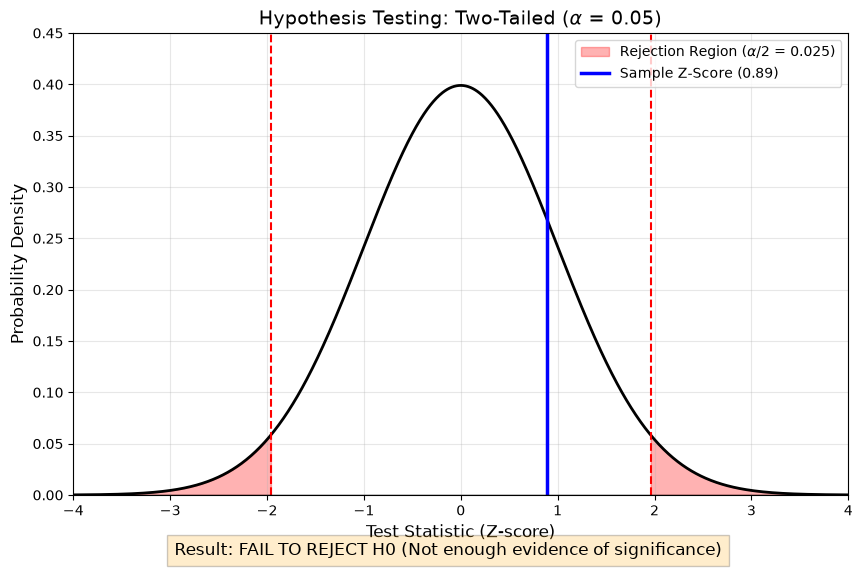

In [2]:
# --- static render for the published website ---
# The sliders above need a live Python kernel. This cell renders the same chart at
# the sliders' default values so the figure is always visible on the website.
plot_critical_region(alpha=0.05, test_type='Two-Tailed')
